In [1]:
from ema_workbench import (
    Model, Policy, ema_logging,
    MultiprocessingEvaluator, save_results, load_results, Scenario
)
from ema_workbench.analysis import prim, cart, parcoords
from sklearn.preprocessing import minmax_scale
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from problem_formulation import get_model_for_problem_formulation
from dike_model_function import DikeNetwork

In [2]:
# Enable logging
ema_logging.log_to_stderr(ema_logging.INFO)

# Load model formulation
dike_model, planning_steps = get_model_for_problem_formulation(3)

# Create a "do nothing" policy (no investment in any lever)
do_nothing = Policy("do nothing", **{lev.name: 0 for lev in dike_model.levers})

# Choose number of scenarios
n_scenarios = 5000  # Literature suggests 1000–10,000, this is a balanced choice

# Run model for scenarios with 1 policy
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=n_scenarios, policies=[do_nothing])
    save_results(results, "scenario_selection.tar.gz")

[MainProcess/INFO] pool started with 12 workers
[MainProcess/INFO] performing 5000 scenarios * 1 policies * 1 model(s) = 5000 experiments
100%|██████████████████████████████████████| 5000/5000 [06:27<00:00, 12.92it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] results saved successfully to C:\Users\milan\PycharmProjects\EMAworkbench\final assignment\scenario_selection.tar.gz
[MainProcess/INFO] terminating pool


In [3]:
# Load experiments and outcomes from saved file
experiments, outcomes = load_results('scenario_selection.tar.gz')

# Combine into one DataFrame
all_data = pd.concat([experiments, pd.DataFrame(outcomes)], axis=1)

[MainProcess/INFO] results loaded successfully from C:\Users\milan\PycharmProjects\EMAworkbench\final assignment\scenario_selection.tar.gz


In [4]:
import numpy as np

# Define outcomes and preferences
outcome_names = [
    'RfR Total Costs',
    'Expected Evacuation Costs',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths'
]

preferences = {
    'RfR Total Costs': +1,
    'Expected Evacuation Costs': +1,
    'A.5 Total Costs': +1,
    'A.5_Expected Number of Deaths': +1,
}

# Compute medians and apply relevance mask
medians = {o: np.median(outcomes[o]) for o in outcome_names}
mask = np.ones(len(all_data), dtype=bool)
for o in outcome_names:
    if preferences[o] == +1:
        mask &= all_data[o] >= medians[o]
    else:
        mask &= all_data[o] <= medians[o]

policy_relevant = all_data[mask].copy()

y = np.ones(len(experiments), dtype=bool)
for o in outcome_names:
    if preferences[o] == +1:
        y &= outcomes[o] >= medians[o]  # higher is worse
    else:
        y &= outcomes[o] <= medians[o]  # lower is worse

In [5]:
# Create filtered sets from the mask y
experiments_of_interest = experiments.loc[y]
outcomes_df = pd.DataFrame({k: v[y] for k, v in outcomes.items()})

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from concurrent.futures import ProcessPoolExecutor
import os
import itertools
import functools
import random

In [7]:

# Import your helper functions
from assignment_10_scenario_selection import find_maxdiverse_scenarios

# STEP 1: Normalize outcomes
scaler = MinMaxScaler()
normalized_outcomes = pd.DataFrame(
    scaler.fit_transform(outcomes_df),
    columns=outcomes_df.columns,
    index=outcomes_df.index
)

# STEP 2: Compute distances
distances = squareform(pdist(normalized_outcomes.values))

# STEP 3: Sample 100,000 combinations of 4
sampled_combinations = [random.sample(range(len(normalized_outcomes)), 4) for _ in range(100000)]

# STEP 4: Parallel diversity scoring
cores = os.cpu_count()
partial_function = functools.partial(find_maxdiverse_scenarios, distances)

with ProcessPoolExecutor(max_workers=cores) as executor:
    worker_data = np.array_split(sampled_combinations, cores)
    results = list(itertools.chain.from_iterable(executor.map(partial_function, worker_data)))

# STEP 5: Select the most diverse set
results.sort(key=lambda entry: entry[0], reverse=True)
diversity_score, best_indices = results[0]

# STEP 6: Print selected scenarios
print(f"\nMost diverse scenario indices: {best_indices}")
selected = experiments.loc[y].iloc[list(best_indices)]
print("\nSelected scenarios:")
print(selected)


Most diverse scenario indices: [ 940 1045 2007 2172]

Selected scenarios:
      A.0_ID flood wave shape    A.1_Bmax A.1_Brate  A.1_pfail    A.2_Bmax  \
940                        48  291.549673      10.0   0.974906  249.022968   
1045                       47  247.481496      10.0   0.884521   63.858461   
2007                       34  228.946631      10.0   0.005351   74.756858   
2172                       69  194.147229      10.0   0.873040  207.819855   

     A.2_Brate  A.2_pfail    A.3_Bmax A.3_Brate  A.3_pfail  ...  \
940        1.0   0.026172  144.461823       1.5   0.843486  ...   
1045       1.5   0.787722  272.228123      10.0   0.139158  ...   
2007       1.0   0.808231  314.878552       1.0   0.684656  ...   
2172       1.5   0.589460   57.202279      10.0   0.427068  ...   

      A.3_DikeIncrease 2 A.4_DikeIncrease 0  A.4_DikeIncrease 1  \
940                    0                  0                   0   
1045                   0                  0                   0 

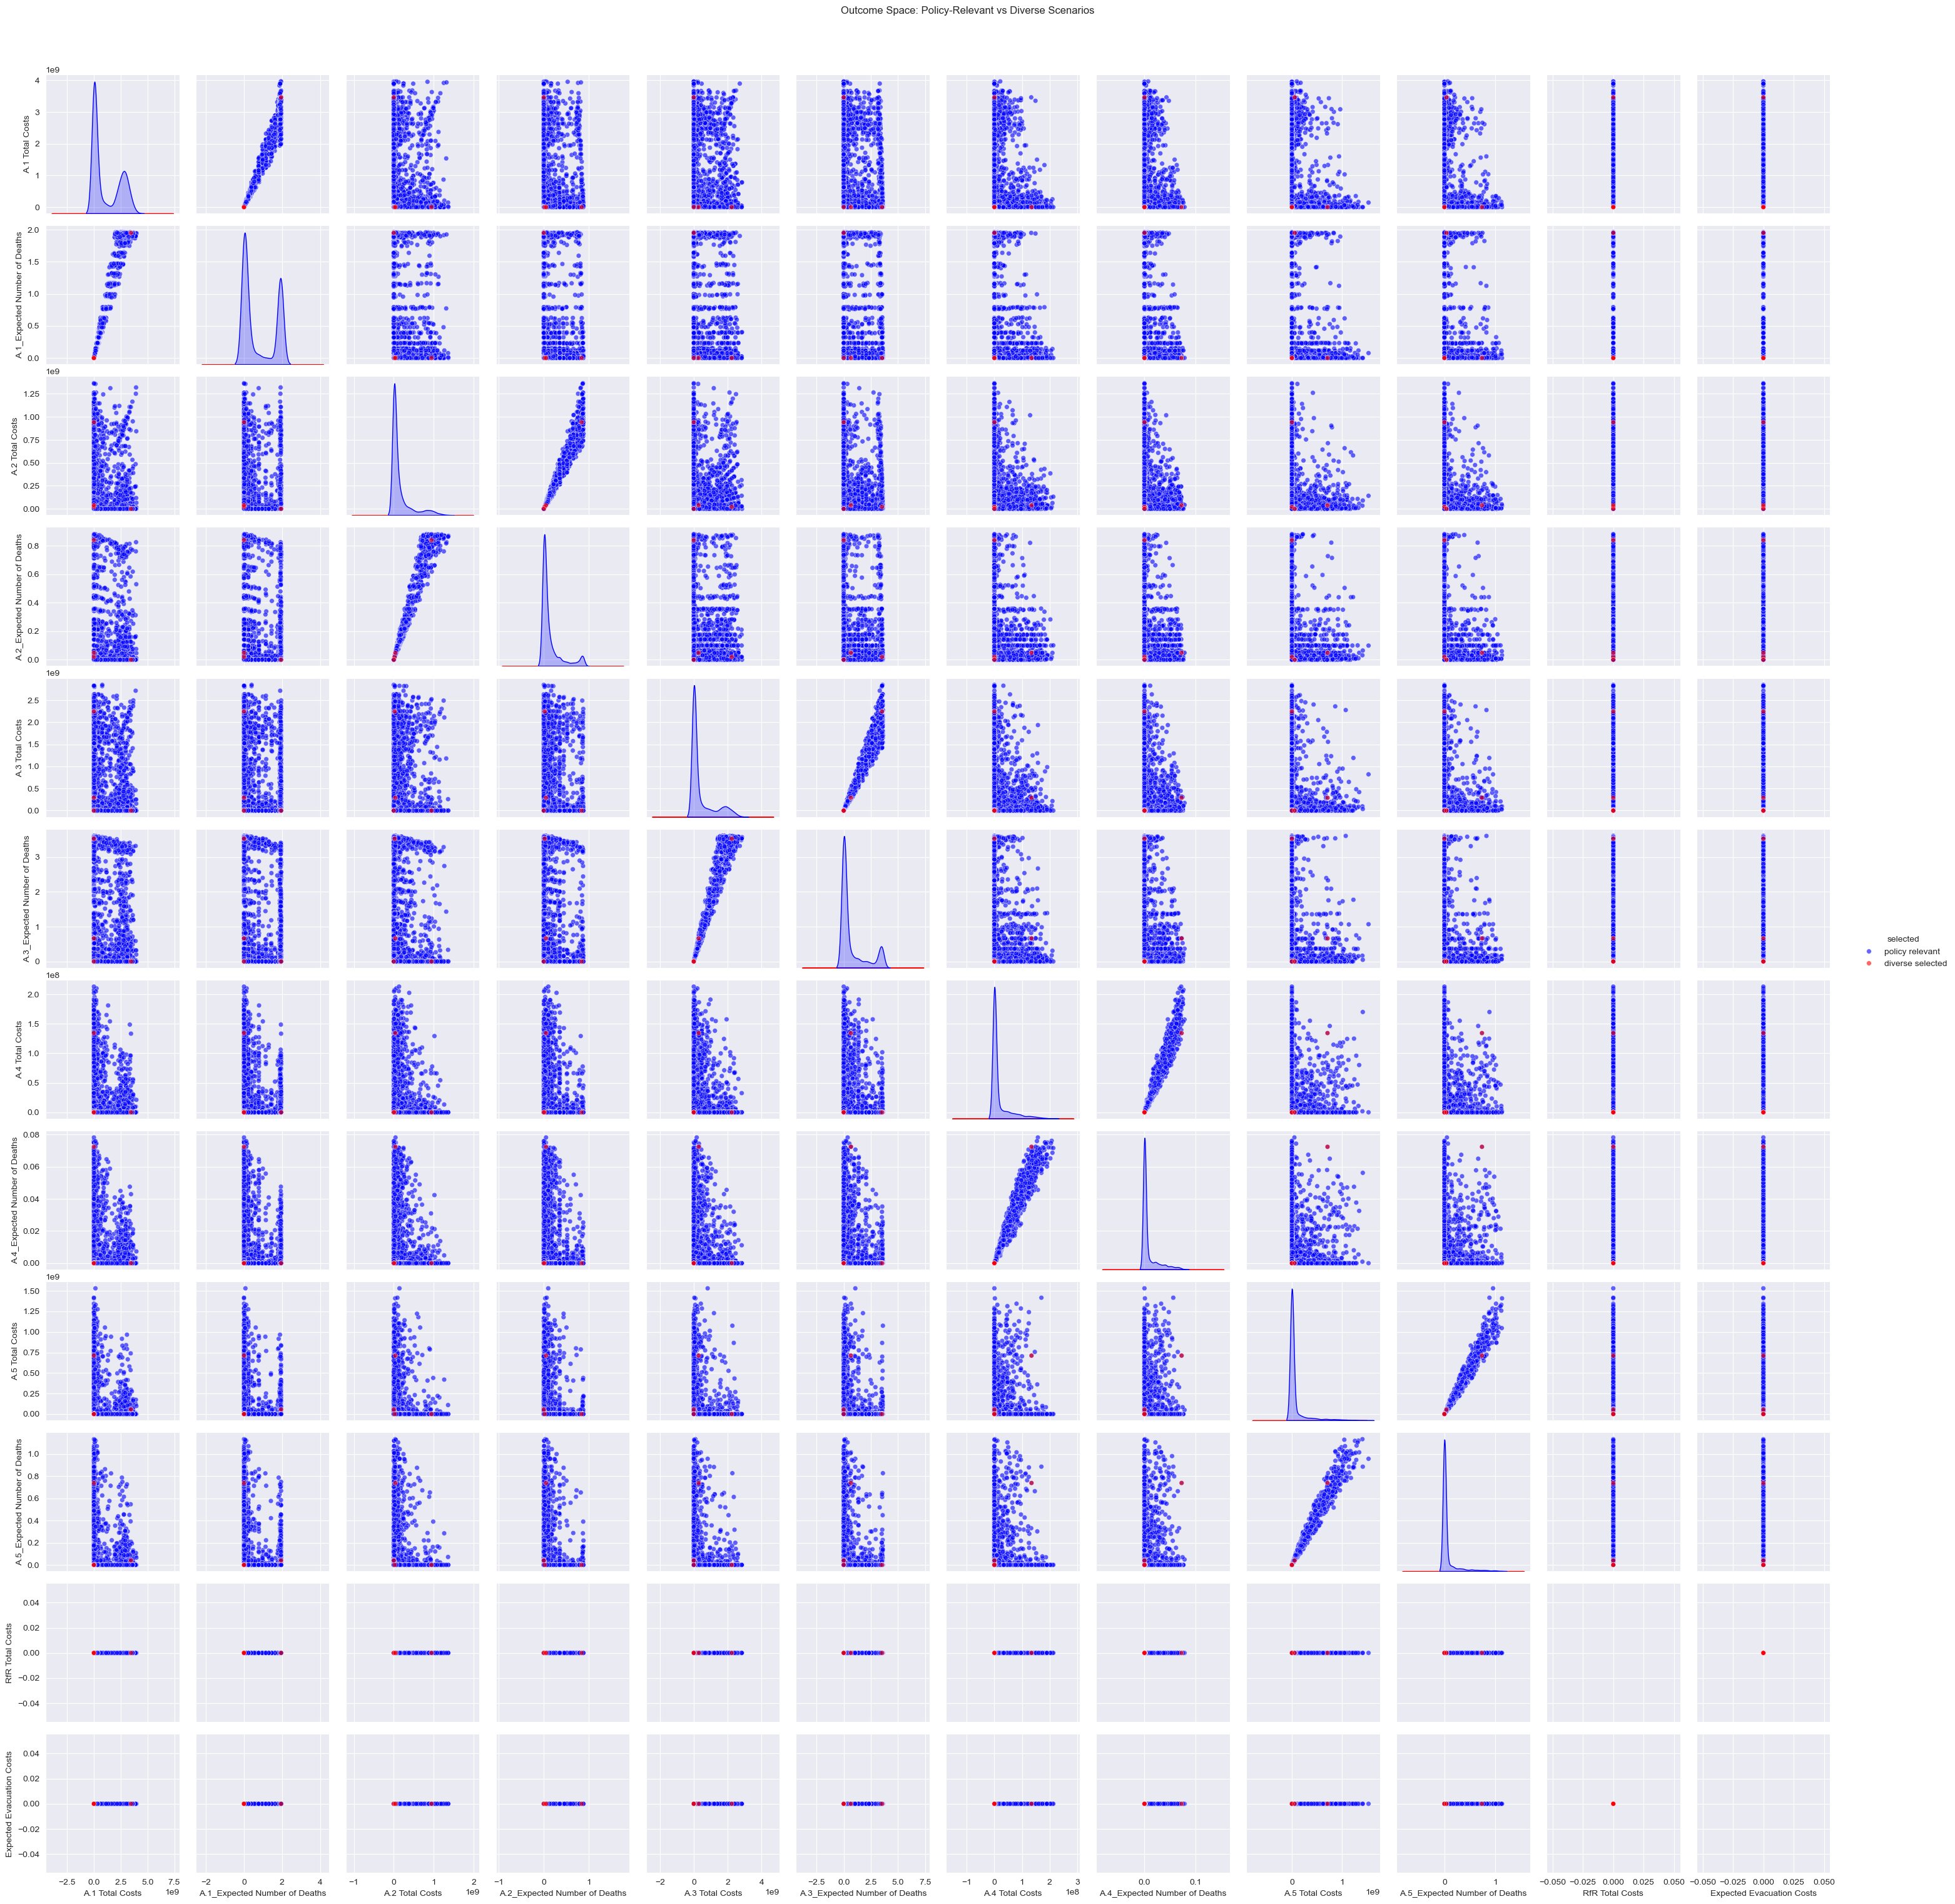

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label outcomes
outcomes_df = outcomes_df.copy()
outcomes_df['selected'] = 'policy relevant'
selected_outcomes = outcomes_df.iloc[list(best_indices)].copy()
selected_outcomes['selected'] = 'diverse selected'

# Combine and plot
combined_outcomes = pd.concat([outcomes_df, selected_outcomes])

sns.pairplot(
    combined_outcomes,
    vars=outcomes_df.columns.drop('selected'),
    hue='selected',
    palette={'policy relevant': 'blue', 'diverse selected': 'red'},
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Outcome Space: Policy-Relevant vs Diverse Scenarios', y=1.02)
plt.show()

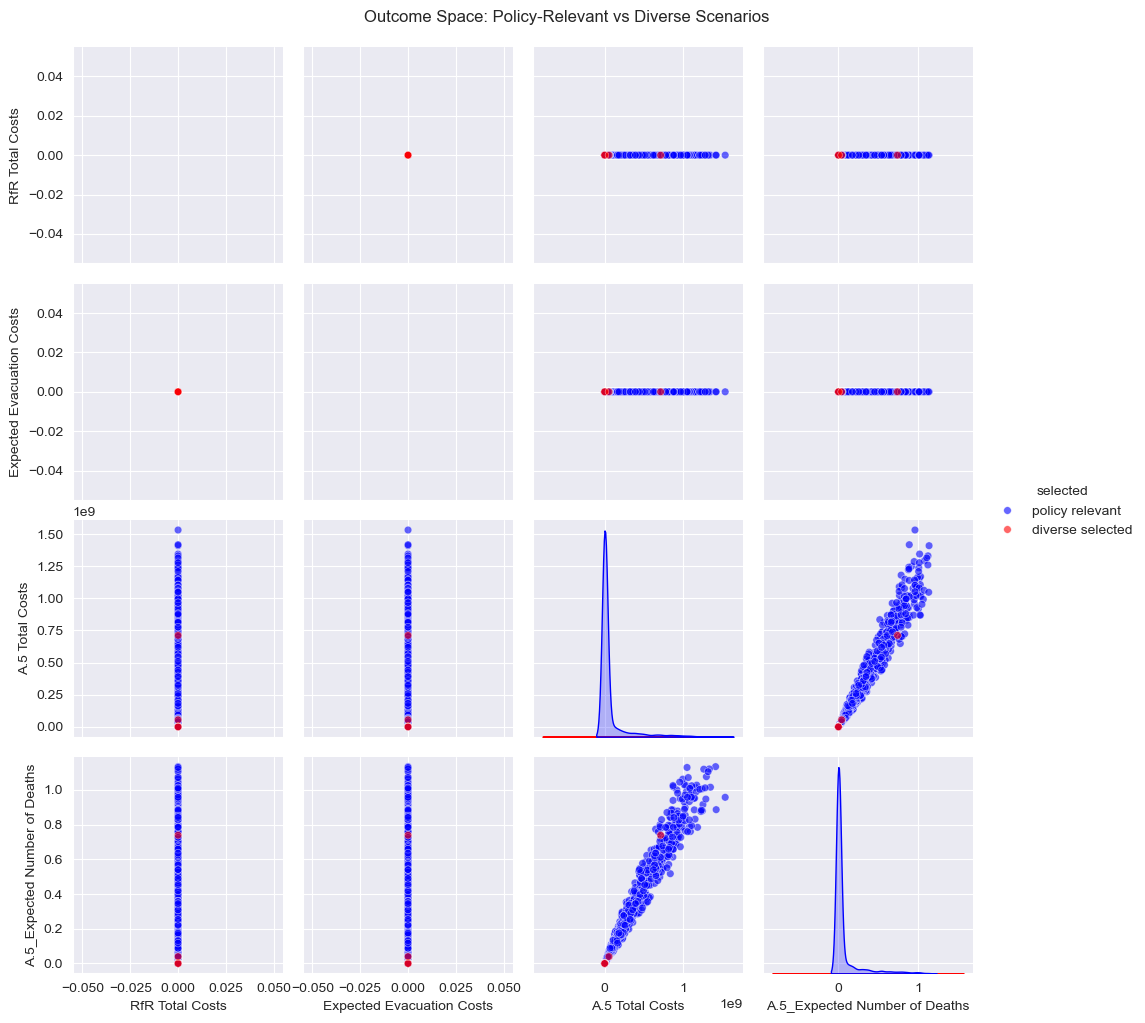

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label outcomes
outcomes_df = outcomes_df.copy()
outcomes_df['selected'] = 'policy relevant'
selected_outcomes = outcomes_df.iloc[list(best_indices)].copy()
selected_outcomes['selected'] = 'diverse selected'

# Combine and plot only selected outcomes
combined_outcomes = pd.concat([outcomes_df, selected_outcomes])

sns.pairplot(
    combined_outcomes,
    vars=[
        'RfR Total Costs',
        'Expected Evacuation Costs',
        'A.5 Total Costs',
        'A.5_Expected Number of Deaths'
    ],
    hue='selected',
    palette={'policy relevant': 'blue', 'diverse selected': 'red'},
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Outcome Space: Policy-Relevant vs Diverse Scenarios', y=1.02)
plt.show()

[MainProcess/INFO] column policy dropped from analysis because it has only one category
[MainProcess/INFO] column model dropped from analysis because it has only one category
[MainProcess/INFO] 5000 points remaining, containing 1201 cases of interest
[MainProcess/INFO] mean: 1.0, mass: 0.0676, coverage: 0.28143213988343047, density: 1.0 restricted_dimensions: 5


coverage       1.0000
density        0.2402
id             0.0000
k           1201.0000
mass           1.0000
mean           0.2402
n           5000.0000
res_dim        0.0000
Name: 0, dtype: float64

Empty DataFrame
Columns: [(box 0, min), (box 0, max), (box 0, qp value), (box 0, qp value)]
Index: []



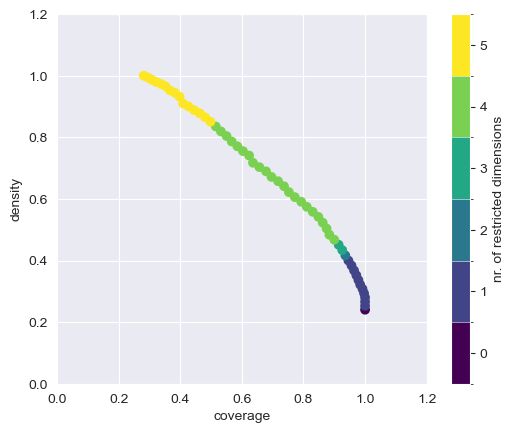

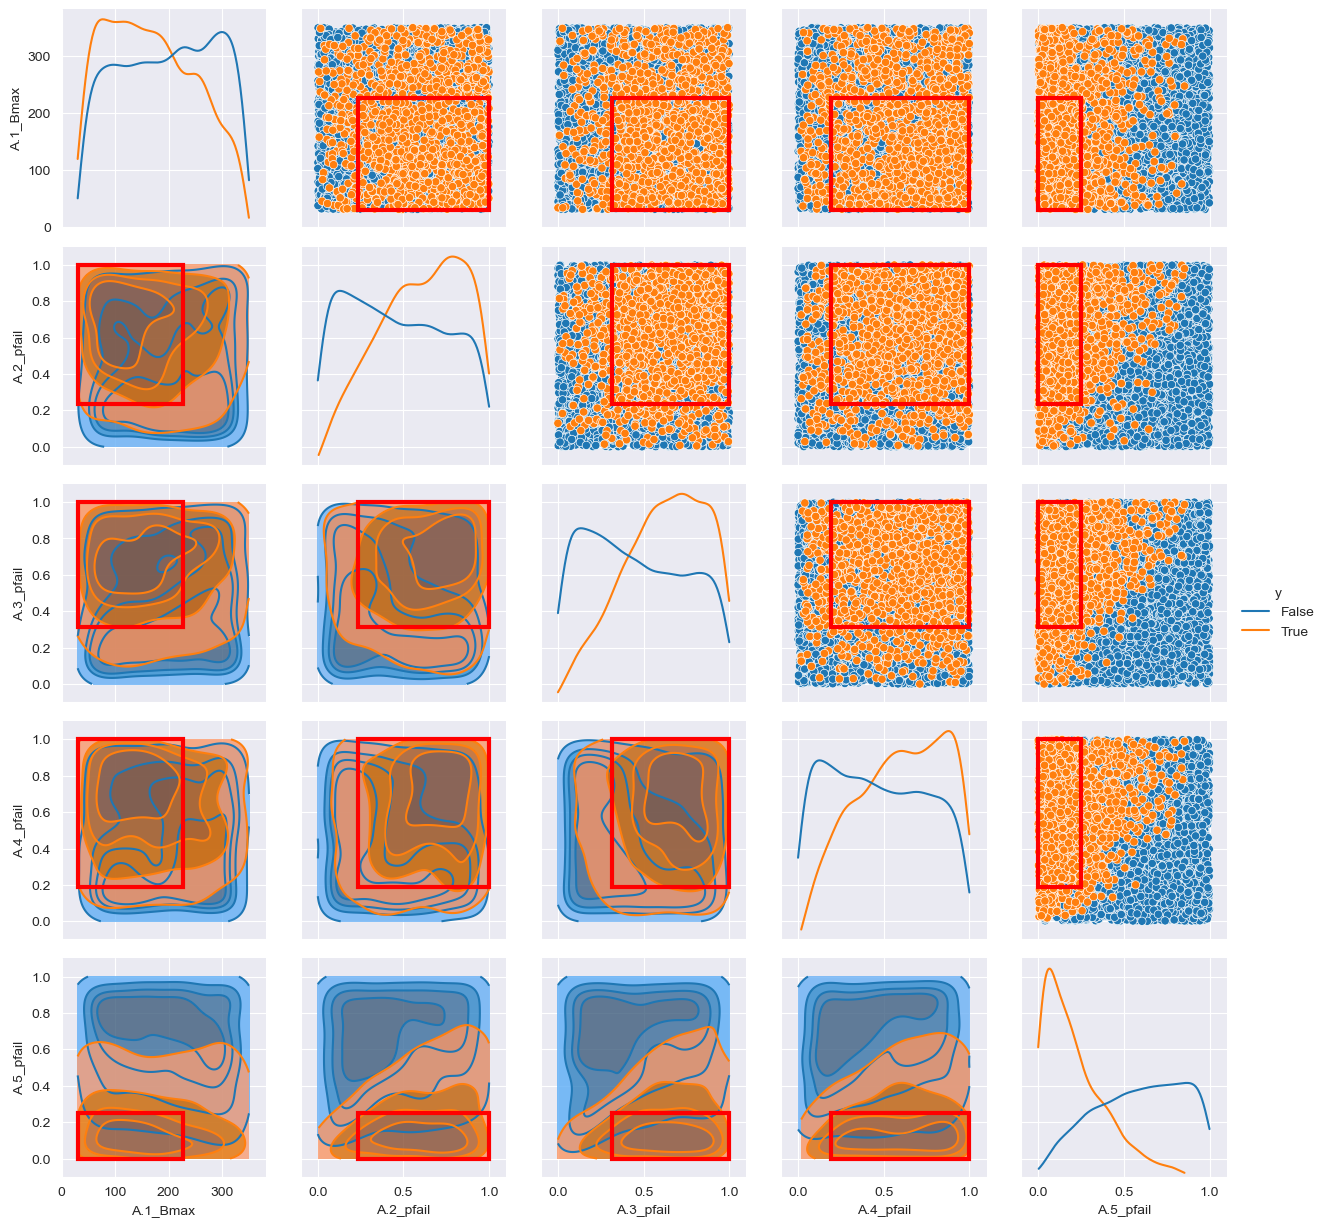

In [10]:
from ema_workbench.analysis import prim

# Binary classification mask for PRIM
y_prim = outcomes_df['A.5_Expected Number of Deaths'] > 0.001

# Use experiments_of_interest (same length as y_prim)

prim_alg = prim.Prim(experiments_of_interest, y_prim, threshold=0.8)
box = prim_alg.find_box()
box.show_tradeoff()
box.inspect(0)
box.show_pairs_scatter()

In [11]:
from ema_workbench.analysis import cart

# Inputs (uncertainties, levers)
x = experiments_of_interest.select_dtypes(include=[np.number])

# Target (can be continuous or binary)
y = outcomes_df['A.5_Expected Number of Deaths'] > 0.001  # classification

# Run CART
cart_results = cart.CART(x=x, y=y)

In [12]:
x

,A.0_ID flood wave shape,A.1_Bmax,A.1_pfail,A.2_Bmax,A.2_pfail,A.3_Bmax,A.3_pfail,A.4_Bmax,A.4_pfail,A.5_Bmax,...,A.2_DikeIncrease 2,A.3_DikeIncrease 0,A.3_DikeIncrease 1,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2
0,37,220.557722,0.845978,61.354102,0.764823,121.184622,0.703636,72.168738,0.802634,50.117261,...,0,0,0,0,0,0,0,0,0,0
1,88,327.146817,0.712198,190.358860,0.186916,65.921464,0.174015,91.964360,0.579404,279.261911,...,0,0,0,0,0,0,0,0,0,0
2,43,254.155322,0.127066,283.929213,0.036357,303.671195,0.405284,165.467111,0.450114,233.697275,...,0,0,0,0,0,0,0,0,0,0
3,121,183.215335,0.763342,280.309318,0.040501,286.258865,0.344113,64.640612,0.658369,327.397012,...,0,0,0,0,0,0,0,0,0,0
4,107,207.164929,0.810340,99.236508,0.990560,339.381525,0.343357,137.125507,0.083592,165.268440,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,81,128.230863,0.717511,292.918075,0.010862,221.568334,0.827527,308.824518,0.911146,231.829296,...,0,0,0,0,0,0,0,0,0,0
4996,100,130.648598,0.523564,152.888545,0.823083,306.056116,0.998197,53.980362,0.877382,321.112077,...,0,0,0,0,0,0,0,0,0,0
4997,116,259.943667,0.006855,306.547898,0.303070,98.440898,0.579592,131.572032,0.025882,272.097434,...,0,0,0,0,0,0,0,0,0,0
4998,69,295.288241,0.125238,159.994978,0.937388,146.686908,0.987914,140.044016,0.394667,342.930577,...,0,0,0,0,0,0,0,0,0,0


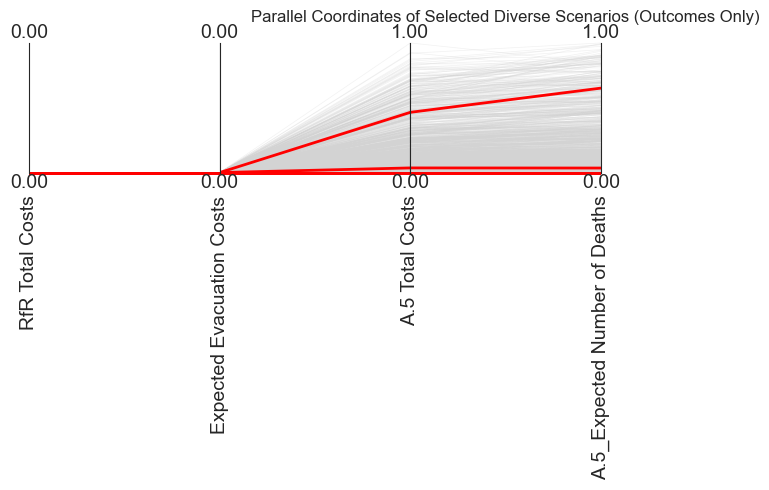

In [13]:
from ema_workbench.analysis import parcoords
from sklearn.preprocessing import minmax_scale
import matplotlib.pyplot as plt

# Merge only outcome values
combined_data = outcomes_df.drop(columns='selected')
vars_of_interest = outcome_names

# Normalize
normalized_all = combined_data[vars_of_interest].copy()
normalized_all[vars_of_interest] = minmax_scale(normalized_all[vars_of_interest])

# Selected 4
selected_out = normalized_all.iloc[list(best_indices)]

# Plot
limits = parcoords.get_limits(normalized_all)
ax = parcoords.ParallelAxes(limits)
ax.plot(normalized_all, color='lightgrey', lw=0.5, alpha=0.3)
ax.plot(selected_out, color='red', lw=2)
plt.title('Parallel Coordinates of Selected Diverse Scenarios (Outcomes Only)')
plt.show()

In [14]:
selected

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
940,48,291.549673,10.0,0.974906,249.022968,1.0,0.026172,144.461823,1.5,0.843486,...,0,0,0,0,0,0,0,940,do nothing,dikesnet
1045,47,247.481496,10.0,0.884521,63.858461,1.5,0.787722,272.228123,10.0,0.139158,...,0,0,0,0,0,0,0,1045,do nothing,dikesnet
2007,34,228.946631,10.0,0.005351,74.756858,1.0,0.808231,314.878552,1.0,0.684656,...,0,0,0,0,0,0,0,2007,do nothing,dikesnet
2172,69,194.147229,10.0,0.873040,207.819855,1.5,0.589460,57.202279,10.0,0.427068,...,0,0,0,0,0,0,0,2172,do nothing,dikesnet


In [15]:
from ema_workbench import Scenario

scenarios = [
    Scenario(f"Scenario {i}", **row.to_dict())
    for i, row in selected.iterrows()
]

In [16]:
from ema_workbench import ema_logging, Scenario
from problem_formulation import get_model_for_problem_formulation  # ensure this is correct
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress, to_problem, epsilon_nondominated, HypervolumeMetric
from ema_workbench import MultiprocessingEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import os


def clean_name(name, prefix="L_"):
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean

def clean_column_names(df, prefix="L_"):
    df = df.copy()
    df.columns = [clean_name(col, prefix=prefix) for col in df.columns]
    return df

objectives_of_interest = [
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths"
]

cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]

if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    for scenario in scenarios:
        for run_id in range(5):
            print(f"\n🔁 Running optimization for scenario: {scenario.name}, run: {run_id}")

            model, steps = get_model_for_problem_formulation(3)

            reference_values = {
                "Bmax": 175,
                "Brate": 1.5,
                "pfail": 0.5,
                "discount rate 0": 3.5,
                "discount rate 1": 3.5,
                "discount rate 2": 3.5,
                "ID flood wave shape": 4,
            }

            scen1 = {}
            for key in model.uncertainties:
                name_split = key.name.split("_")
                key_id = name_split[1] if len(name_split) > 1 else key.name
                scen1[key.name] = reference_values[key_id]

            ref_scenario = Scenario("reference", **scen1)

            cleaned_lever_names = [clean_name(l.name, "L_") for l in model.levers]
            cleaned_outcome_names = [clean_name(o.name, "O_") for o in model.outcomes]

            archive_path = f"./archives/optimization_{scenario.name}_run{run_id}.tar.gz"
            os.makedirs("./archives", exist_ok=True)
            if os.path.exists(archive_path):
                os.remove(archive_path)

            convergence_metrics = [
                ArchiveLogger(
                    "./archives",
                    cleaned_lever_names,
                    cleaned_outcome_names,
                    base_filename=f"optimization_{scenario.name}_run{run_id}.tar.gz",
                ),
                EpsilonProgress(),
            ]

            with MultiprocessingEvaluator(model) as evaluator:
                results, convergence = evaluator.optimize(
                    nfe=100,
                    searchover='levers',
                    convergence=convergence_metrics,
                    epsilons=[0.01] * len(model.outcomes),
                    reference=ref_scenario
                )

            archive_test = ArchiveLogger.load_archives(archive_path)
            archive_test_clean = {k: clean_column_names(v) for k, v in archive_test.items()}
            reference_set_clean = clean_column_names(results)

            for lever in model.levers:
                lever.name = clean_name(lever.name, "L_")

            names_to_keep = []
            for o in model.outcomes:
                cleaned = clean_name(o.name, prefix="O_")
                if cleaned in cleaned_objectives_of_interest:
                    names_to_keep.append(o.name)

            for name in list(model.outcomes.keys()):
                if name not in names_to_keep:
                    del model.outcomes[name]

            for o in model.outcomes:
                o.name = clean_name(o.name, prefix="O_")

            print(f"✅ Filtered outcomes for scenario {scenario.name} (run {run_id}):")
            for o in model.outcomes:
                print(o.name)

            problem = to_problem(model, searchover="levers")
            problem._outcome_names = cleaned_objectives_of_interest
            cleaned_lever_names = problem.parameter_names

            reference_set_reduced = reference_set_clean[cleaned_objectives_of_interest + cleaned_lever_names]
            archive_test_reduced = {
                k: v[cleaned_objectives_of_interest + cleaned_lever_names] for k, v in archive_test_clean.items()
            }

            reference_set_final = reference_set_reduced.copy()

            if len(reference_set_final) == 0:
                print(f"⚠️ No non-dominated solutions in run {run_id} of {scenario.name}. Skipping HV calc.")
                continue  # skip the rest of this run

            def calculate_convergence_metrics(problem, archives_file, reference_set):
                hv = HypervolumeMetric(reference_set, problem)
                metrics = []
                for nfe, archive in archives_file.items():
                    scores = {"hypervolume": hv.calculate(archive), "nfe": nfe}
                    metrics.append(scores)
                df = pd.DataFrame.from_dict(metrics)
                df.sort_values(by="nfe", inplace=True, ignore_index=True)
                return df

            metrics = calculate_convergence_metrics(problem, archive_test_reduced, reference_set_final)
            if metrics.empty:
                print(f"⚠️ No valid metrics in run {run_id} of {scenario.name}.")
                continue
            print(metrics)

            epsilon_nfe = convergence["nfe"]
            epsilon_values = convergence["epsilon_progress"]
            hv_nfe = metrics["nfe"]
            hv_values = metrics["hypervolume"]

            metrics["seed"] = run_id
            metrics["scenario"] = scenario.name
            metrics["epsilon_progress"] = [v for v in epsilon_values]  # assuming alignment by index

            # Save metrics to disk
            save_dir = "./convergence_metrics"
            os.makedirs(save_dir, exist_ok=True)
            metrics_file = os.path.join(save_dir, f"metrics_{scenario.name}_run{run_id}.csv")
            metrics.to_csv(metrics_file, index=False)
            print(f"💾 Saved convergence metrics to {metrics_file}")


🔁 Running optimization for scenario: Scenario 940, run: 0


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 100/100 [00:07<00:00, 14.09it/s]
[MainProcess/INFO] optimization completed, found 83 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario Scenario 940 (run 0):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0      0.00000    0
1      0.99067  100
💾 Saved convergence metrics to ./convergence_metrics\metrics_Scenario 940_run0.csv

🔁 Running optimization for scenario: Scenario 940, run: 1


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 100/100 [00:07<00:00, 13.99it/s]
[MainProcess/INFO] optimization completed, found 78 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario Scenario 940 (run 1):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0     0.000000    0
1     0.983135  100
💾 Saved convergence metrics to ./convergence_metrics\metrics_Scenario 940_run1.csv

🔁 Running optimization for scenario: Scenario 940, run: 2


...

✅ Filtered outcomes for scenario Scenario 2172 (run 2):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0     0.000000    0
1     0.999643  100
💾 Saved convergence metrics to ./convergence_metrics\metrics_Scenario 2172_run2.csv

🔁 Running optimization for scenario: Scenario 2172, run: 3


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 100/100 [00:07<00:00, 14.14it/s]
[MainProcess/INFO] optimization completed, found 64 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario Scenario 2172 (run 3):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0          0.0    0
1          1.0  100
💾 Saved convergence metrics to ./convergence_metrics\metrics_Scenario 2172_run3.csv

🔁 Running optimization for scenario: Scenario 2172, run: 4


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 100/100 [00:07<00:00, 13.92it/s]
[MainProcess/INFO] optimization completed, found 69 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario Scenario 2172 (run 4):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0     0.000000    0
1     0.999558  100
💾 Saved convergence metrics to ./convergence_metrics\metrics_Scenario 2172_run4.csv


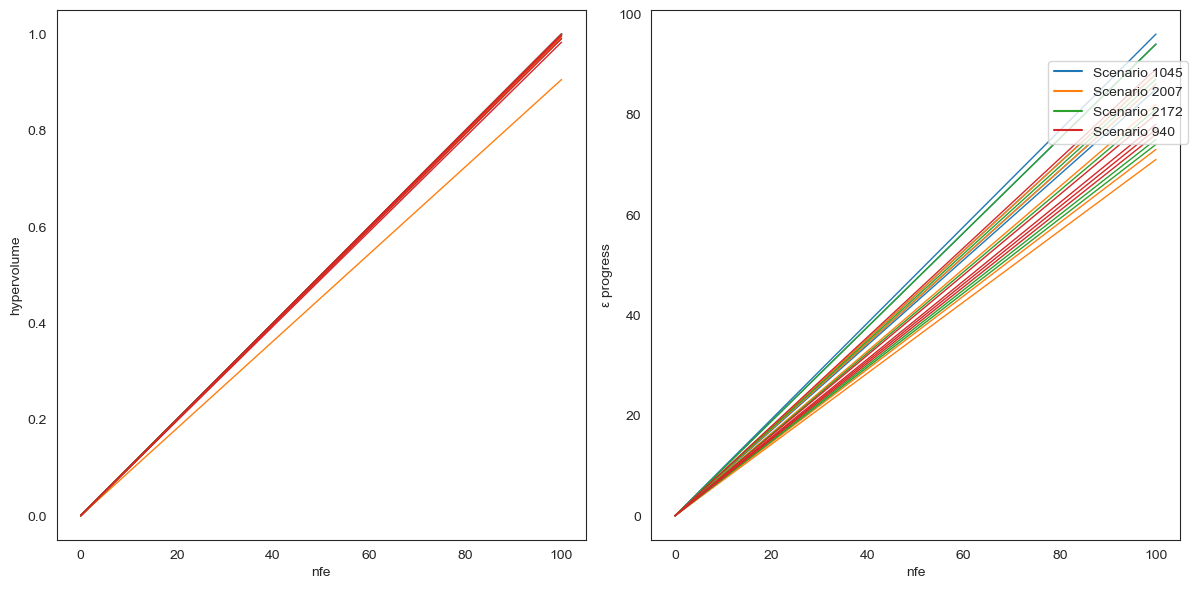

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load all saved metrics
all_metrics = []
metrics_dir = "./convergence_metrics"

for file in os.listdir(metrics_dir):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(metrics_dir, file))
        all_metrics.append(df)

convergence = pd.concat(all_metrics, ignore_index=True)

# Plotting
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
colors = sns.color_palette()
legend_items = []

for (scenario_name, scores), color in zip(convergence.groupby("scenario"), colors):
    legend_items.append((plt.Line2D([0, 1], [0, 1], color=color), scenario_name))
    for seed, score in scores.groupby("seed"):
        ax1.plot(score.nfe, score.hypervolume, c=color, lw=1)
        ax2.plot(score.nfe, score.epsilon_progress, c=color, lw=1)

ax1.set_ylabel('hypervolume')
ax1.set_xlabel('nfe')
ax2.set_ylabel('ε progress')
ax2.set_xlabel('nfe')
artists, labels = zip(*legend_items)
fig.legend(artists, labels, bbox_to_anchor=(1, 0.9))
plt.tight_layout()
plt.show()